# "Old" Approach - no proper train-test split before augmentation

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded X: (54616, 512), y: (54616,)
Training RBF Kernel SVC...
Training complete. Generating predictions...
Accuracy: 0.4834
Macro-F1: 0.4143
Weighted-F1: 0.4842


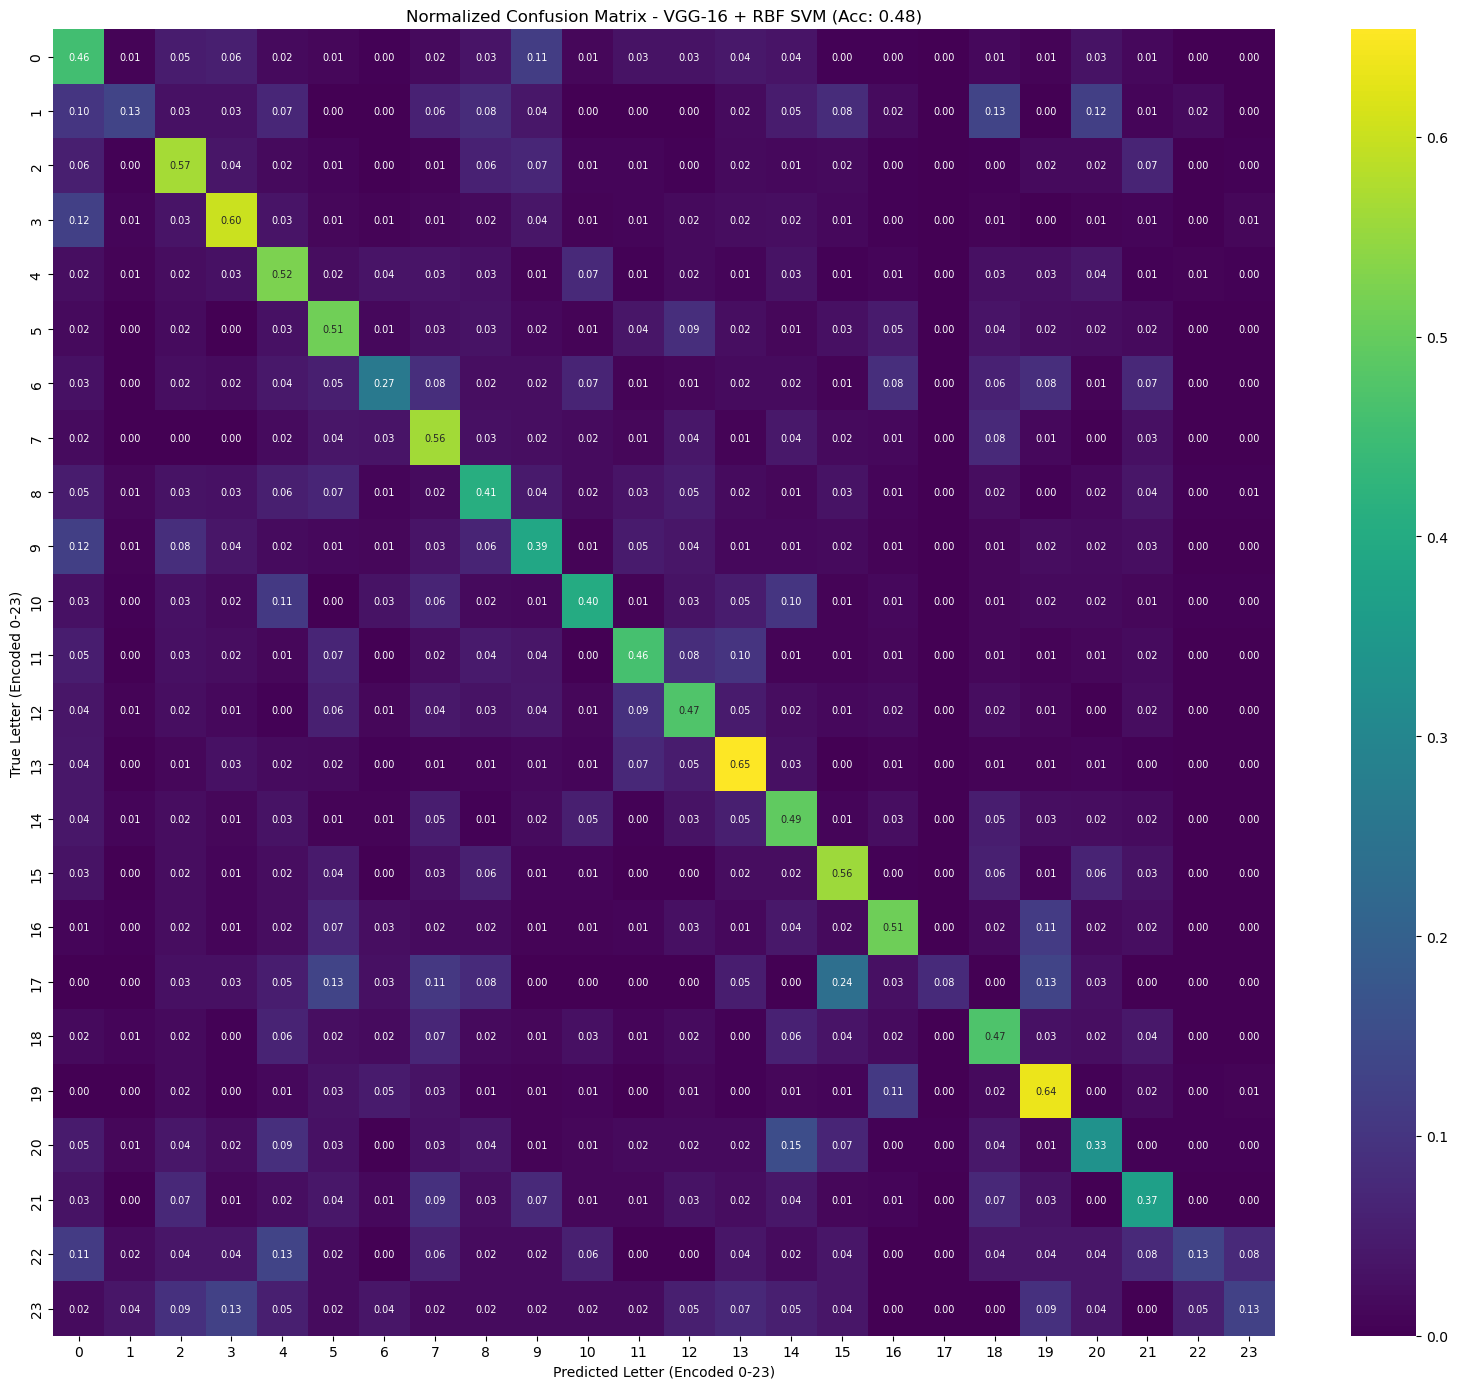


Classification Report (per class):
              precision    recall  f1-score   support

           0       0.56      0.46      0.50      1044
           1       0.18      0.13      0.15        99
           2       0.35      0.57      0.43       304
           3       0.51      0.60      0.55       378
           4       0.57      0.52      0.55       787
           5       0.45      0.51      0.48       533
           6       0.21      0.27      0.23       166
           7       0.40      0.56      0.47       433
           8       0.46      0.41      0.43       588
           9       0.28      0.39      0.33       355
          10       0.42      0.40      0.41       404
          11       0.46      0.46      0.46       479
          12       0.58      0.47      0.52       975
          13       0.53      0.65      0.59       543
          14       0.60      0.49      0.54       994
          15       0.42      0.56      0.48       224
          16       0.60      0.51      0.55  

final_accuracy,0.48343
final_macro_f1,0.4143
final_weighted_f1,0.48416


In [1]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Define hyperparameters centrally for W&B Config Tracking
# This dictionary will populate the "Overview" tab in your Weights & Biases dashboard.
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               # Regularization parameter
    "gamma": "scale",       # Kernel coefficient. 'scale' uses 1 / (n_features * X.var())
    "class_weight": "balanced", 
    "cache_size": 4000,     # CRITICAL: Allocates 4GB of Mac Unified Memory to the Gram matrix
    "test_size": 0.20,
    "random_state": 42
}

# 2. Initialize Weights & Biases with the config dictionary
wandb.init(project="odysseus", name="vgg16_rbf_svm", job_type="modeling", config=config_params)
# Map the tracked config back to a local variable for clean instantiation
config = wandb.config

# 3. Load the extracted arrays
DATA_DIR = "../data/extracted_features"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 4. Stratified Train-Test Split using tracked config parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config.test_size, 
    random_state=config.random_state, 
    stratify=y
)

# 5. Standard Scaling (Even more critical for RBF kernels than Linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Non-Linear SVM
print("Training RBF Kernel SVC...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 7. Predictions
print("Training complete. Generating predictions...")
y_pred = svm_clf.predict(X_test_scaled)

# 8. Calculate Metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# 9. Log Final Summary Metrics to W&B
# wandb.run.summary permanently pins these metrics to the table view in your dashboard
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class):")
print(classification_report(y_test, y_pred))

# Close the W&B run
wandb.finish()

Loaded X: (54616, 256), y: (54616,)
Training RBF Kernel SVC...
Training complete. Generating predictions...
Accuracy: 0.3489
Macro-F1: 0.3019
Weighted-F1: 0.3524


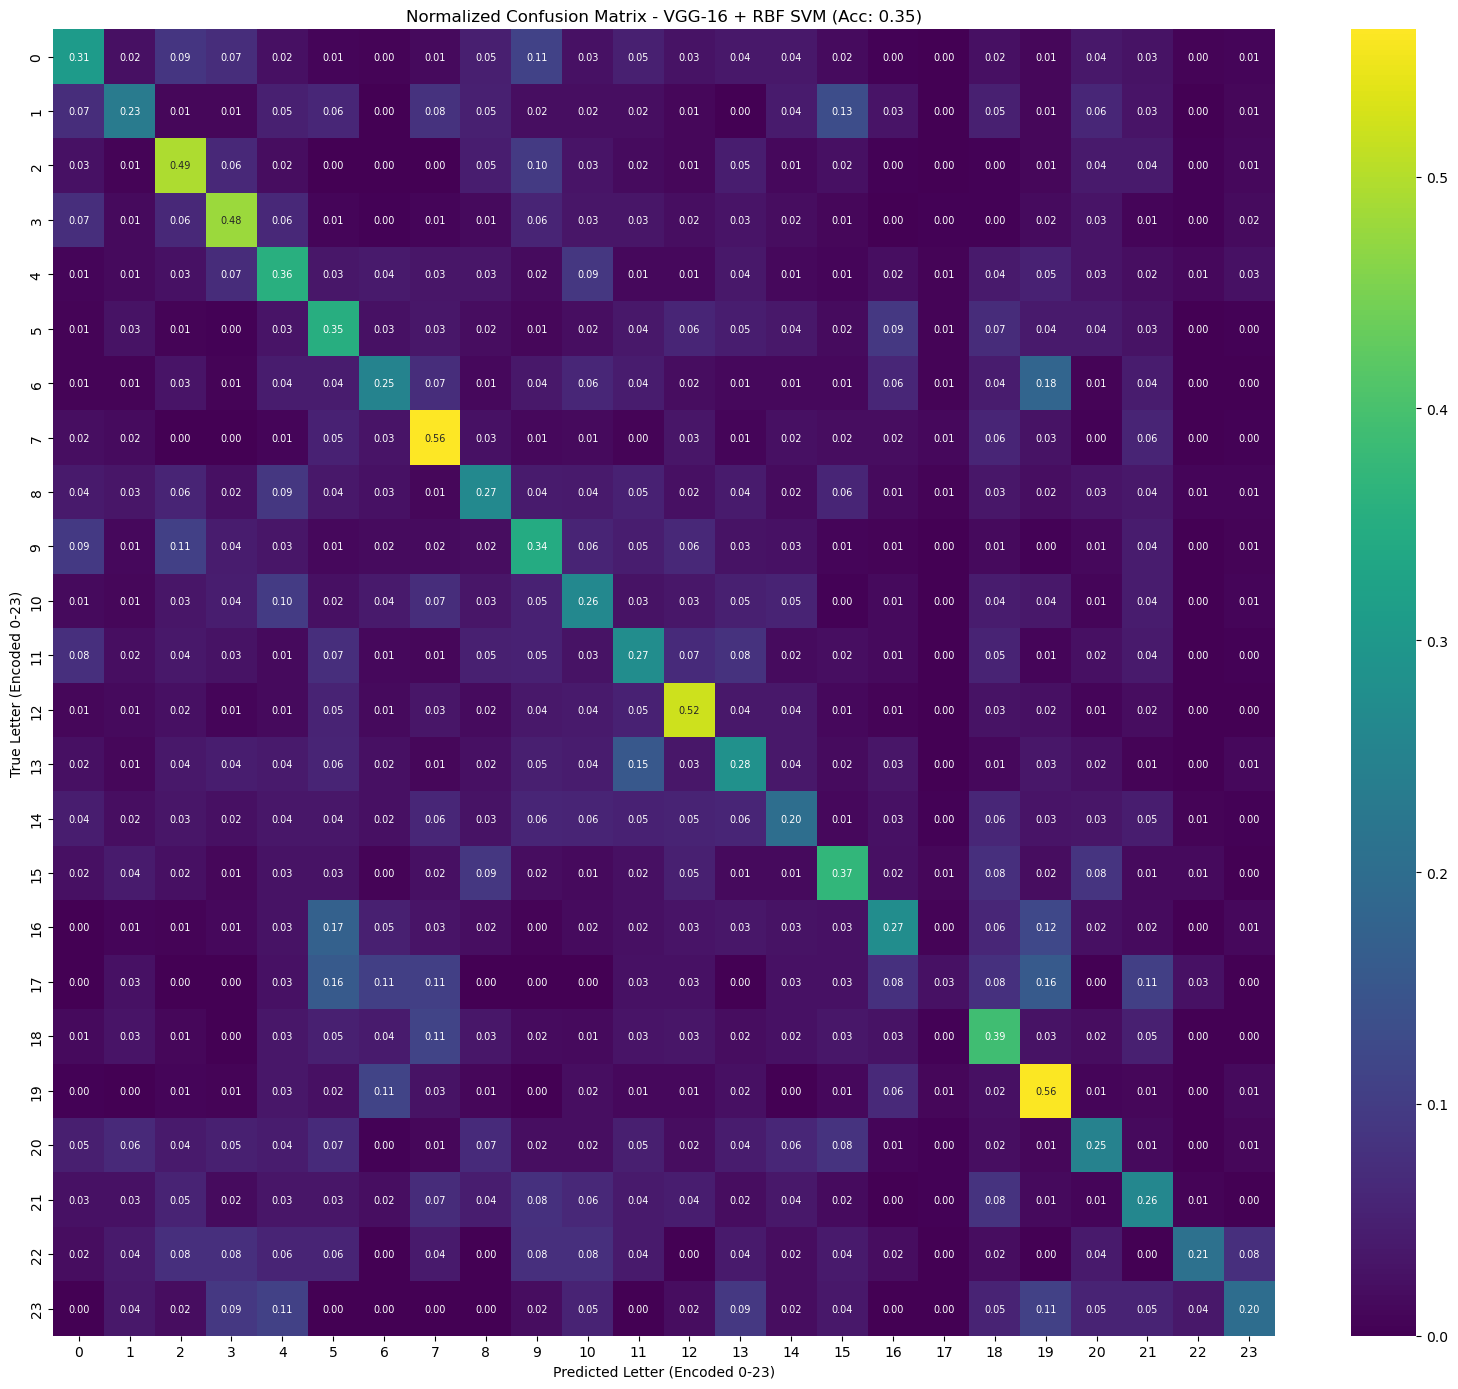


Classification Report (per class):
              precision    recall  f1-score   support

           0       0.55      0.31      0.39      1044
           1       0.10      0.23      0.14        99
           2       0.28      0.49      0.36       304
           3       0.37      0.48      0.42       378
           4       0.43      0.36      0.39       787
           5       0.29      0.35      0.32       533
           6       0.13      0.25      0.17       166
           7       0.40      0.56      0.47       433
           8       0.33      0.27      0.29       588
           9       0.21      0.34      0.26       355
          10       0.21      0.26      0.23       404
          11       0.24      0.27      0.25       479
          12       0.61      0.52      0.56       975
          13       0.29      0.28      0.29       543
          14       0.43      0.20      0.27       994
          15       0.27      0.37      0.31       224
          16       0.43      0.27      0.34  

final_accuracy,0.34886
final_macro_f1,0.30189
final_weighted_f1,0.35235


In [2]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Define hyperparameters centrally for W&B Config Tracking
# This dictionary will populate the "Overview" tab in your Weights & Biases dashboard.
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               # Regularization parameter
    "gamma": "scale",       # Kernel coefficient. 'scale' uses 1 / (n_features * X.var())
    "class_weight": "balanced", 
    "cache_size": 4000,     # CRITICAL: Allocates 4GB of Mac Unified Memory to the Gram matrix
    "test_size": 0.20,
    "random_state": 42,
    "vgg16_block": 3
}

# 2. Initialize Weights & Biases with the config dictionary
wandb.init(project="odysseus", name="vgg16_3blocks_rbf_svm", job_type="modeling", config=config_params)
# Map the tracked config back to a local variable for clean instantiation
config = wandb.config

# 3. Load the extracted arrays
DATA_DIR = "../data/extracted_features_early"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 4. Stratified Train-Test Split using tracked config parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config.test_size, 
    random_state=config.random_state, 
    stratify=y
)

# 5. Standard Scaling (Even more critical for RBF kernels than Linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Non-Linear SVM
print("Training RBF Kernel SVC...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 7. Predictions
print("Training complete. Generating predictions...")
y_pred = svm_clf.predict(X_test_scaled)

# 8. Calculate Metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# 9. Log Final Summary Metrics to W&B
# wandb.run.summary permanently pins these metrics to the table view in your dashboard
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class):")
print(classification_report(y_test, y_pred))

# Close the W&B run
wandb.finish()

Loaded X: (125280, 2048), y: (125280,)
Training RBF Kernel SVC on 2048-D SPP features...
Accuracy: 0.6750
Macro-F1: 0.6738


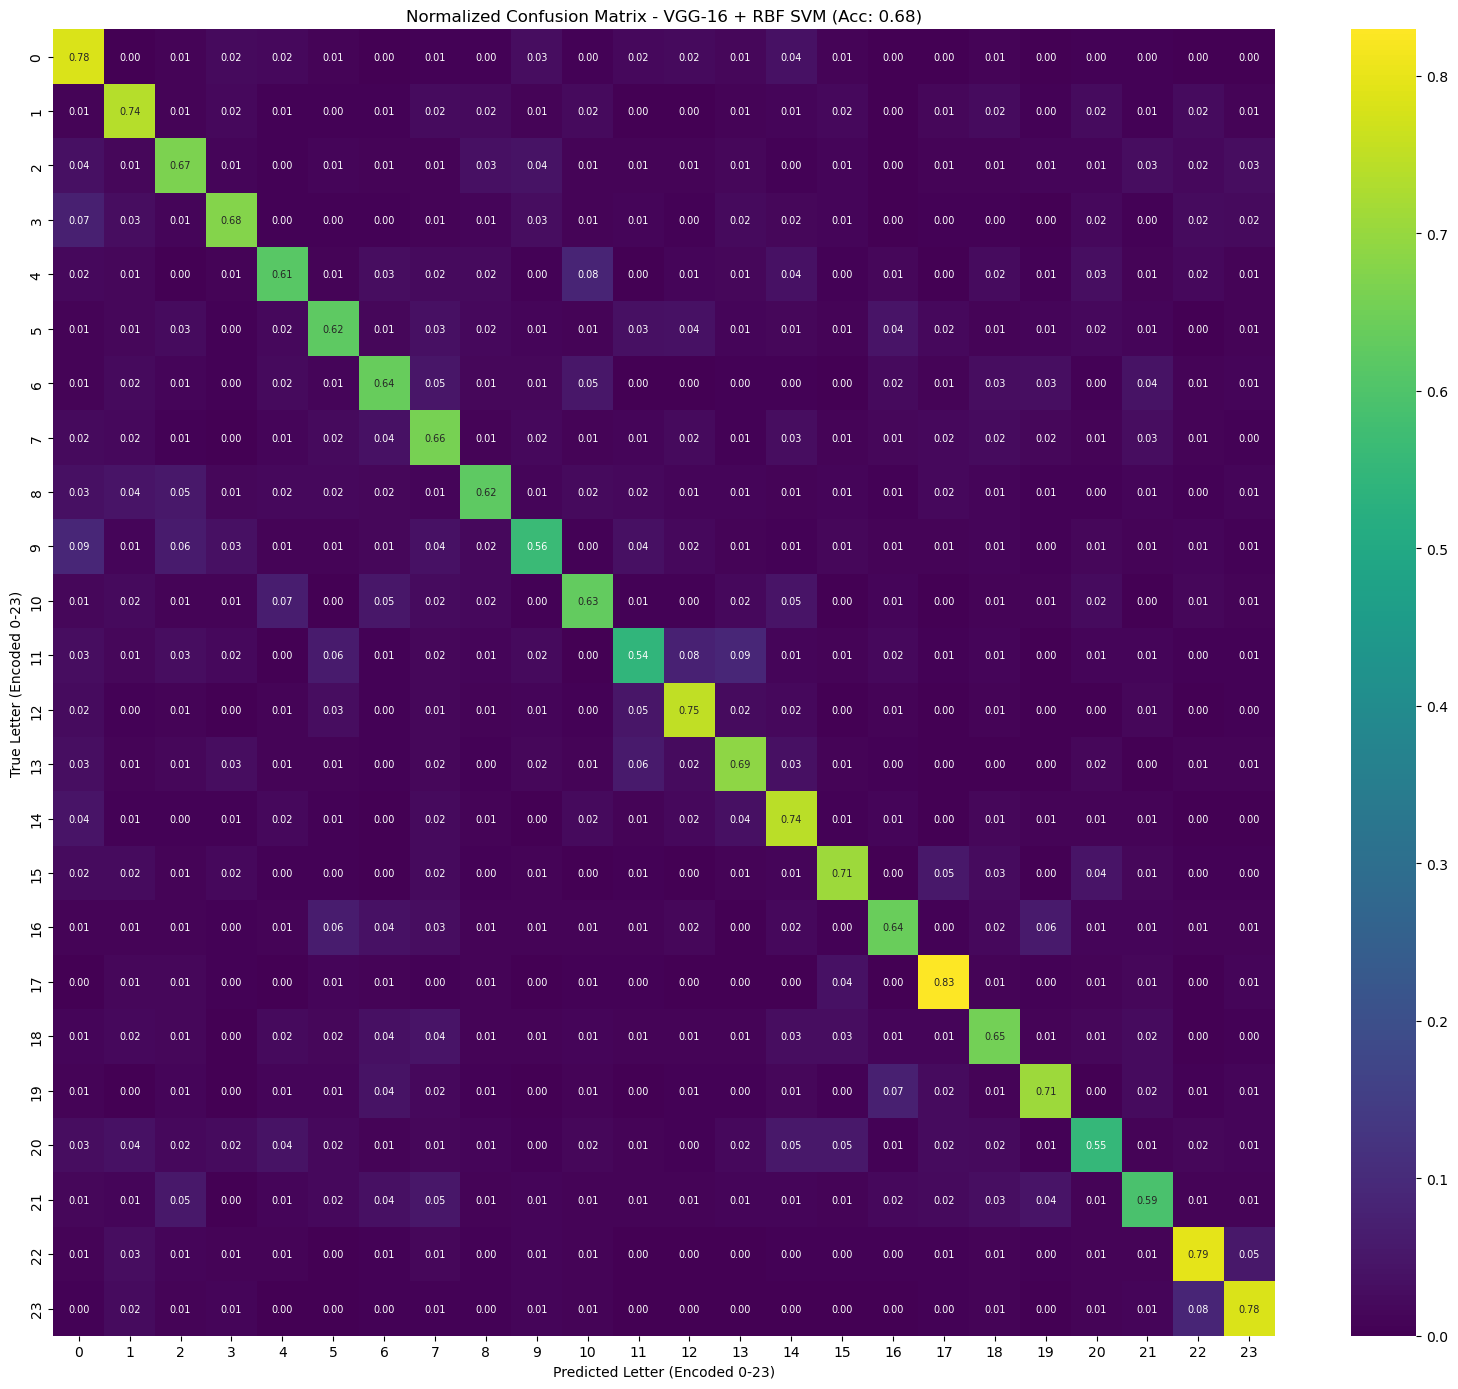

              precision    recall  f1-score   support

           0       0.59      0.78      0.68      1044
           1       0.66      0.74      0.70      1044
           2       0.62      0.67      0.64      1044
           3       0.73      0.68      0.70      1044
           4       0.65      0.61      0.63      1044
           5       0.64      0.62      0.63      1044
           6       0.64      0.64      0.64      1044
           7       0.58      0.66      0.62      1044
           8       0.71      0.62      0.66      1044
           9       0.66      0.56      0.61      1044
          10       0.66      0.63      0.64      1044
          11       0.64      0.54      0.59      1044
          12       0.71      0.75      0.73      1044
          13       0.67      0.69      0.68      1044
          14       0.64      0.74      0.69      1044
          15       0.73      0.71      0.72      1044
          16       0.69      0.64      0.67      1044
          17       0.76    

final_accuracy,0.67501
final_macro_f1,0.67379


In [2]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Update Config for W&B
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,   # Dataset is now physically balanced with artificially augmented data
    "pooling_strategy": "SPP_2x2",
    "feature_dimensions": 2048,
    "cache_size": 4000,     # M3 Mac memory allocation
    "test_size": 0.20,
    "random_state": 42
}

wandb.init(project="odysseus", name="vgg16_spp2x2_augmented_rbf", job_type="modeling", config=config_params)
config = wandb.config

# 2. Load the NEW SPP 2048-dimensional arrays
DATA_DIR = "../data/extracted_features_SPP"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.test_size, random_state=config.random_state, stratify=y
)

# 4. Standard Scaling (Crucial for 2048-d vectors)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the SVM (No class weights)
print("Training RBF Kernel SVC on 2048-D SPP features...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 6. Evaluate and Log
y_pred = svm_clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")

wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print(classification_report(y_test, y_pred))
wandb.finish()

# NEW TRAIN/TEST SPLIT FEATURES
updated features used below

In [5]:
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def train_and_evaluate_svm(config_params, data_dir, run_name, project_name="odysseus"):
    """
    Universal function to load pre-split data, train an SVM, evaluate it, and log to W&B.
    """
    # 1. Initialize Weights & Biases
    wandb.init(project=project_name, name=run_name, job_type="modeling", config=config_params)
    config = wandb.config
    
    print(f"\n{'='*50}\nStarting Experiment: {run_name}\n{'='*50}")

    # 2. Load the pre-split arrays (Data Leakage explicitly prevented here)
    X_train = np.load(os.path.join(data_dir, "X_train.npy"))
    y_train = np.load(os.path.join(data_dir, "y_train.npy"))
    X_test = np.load(os.path.join(data_dir, "X_test.npy"))
    y_test = np.load(os.path.join(data_dir, "y_test.npy"))

    print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
    print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

    # 3. Standard Scaling 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Train the SVM
    print(f"Training RBF Kernel SVC on {X_train.shape[1]}-D features...")
    svm_clf = SVC(
        kernel=config.kernel,
        C=config.C,
        gamma=config.gamma,
        class_weight=config.class_weight,
        cache_size=config.cache_size,
        random_state=config.random_state,
        verbose=False
    )
    svm_clf.fit(X_train_scaled, y_train)

    # 5. Evaluate
    print("Training complete. Generating predictions...")
    y_pred = svm_clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

    # 6. Log Summary Metrics to W&B
    wandb.run.summary["final_accuracy"] = accuracy
    wandb.run.summary["final_macro_f1"] = macro_f1
    wandb.run.summary["final_weighted_f1"] = weighted_f1

    # 7. Generate and Log Annotated Heatmap
    greek_labels = [
        "Alpha (Α)", "Beta (Β)", "Chi (Χ)", "Delta (Δ)", "Epsilon (Ε)", 
        "Eta (Η)", "Gamma (Γ)", "Iota (Ι)", "Kappa (Κ)", "Lambda (Λ)", 
        "LSigma (Ϲ)", "Mu (Μ)", "Nu (Ν)", "Omega (Ω)", "Omicron (Ο)", 
        "Phi (Φ)", "Pi (Π)", "Psi (Ψ)", "Rho (Ρ)", "Tau (Τ)", "Theta (Θ)", 
        "Upsilon (Υ)", "Xi (Ξ)", "Zeta (Ζ)"
    ]
    
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    plt.figure(figsize=(18, 16))
    
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7},
        xticklabels=greek_labels, yticklabels=greek_labels
    )
    
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})
    plt.title(f"Normalized Confusion Matrix - {run_name} (Acc: {accuracy:.2f})")
    plt.xlabel("Predicted Letter (Encoded 0-23)")
    plt.ylabel("True Letter (Encoded 0-23)")
    plt.tight_layout()

    # Save with unique name to prevent overwriting
    cm_filename = f"svm_cm_{run_name}.png"
    plt.savefig(cm_filename, dpi=300)
    wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
    plt.show()

    # 8. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Close the W&B run cleanly
    wandb.finish()


Starting Experiment: vgg16_late_gap_rbf
Loaded Train Set - X: (100224, 512), y: (100224,)
Loaded Test Set  - X: (10977, 512), y: (10977,)
Training RBF Kernel SVC on 512-D features...
Training complete. Generating predictions...
Accuracy: 0.5024 | Macro-F1: 0.4292 | Weighted-F1: 0.4912


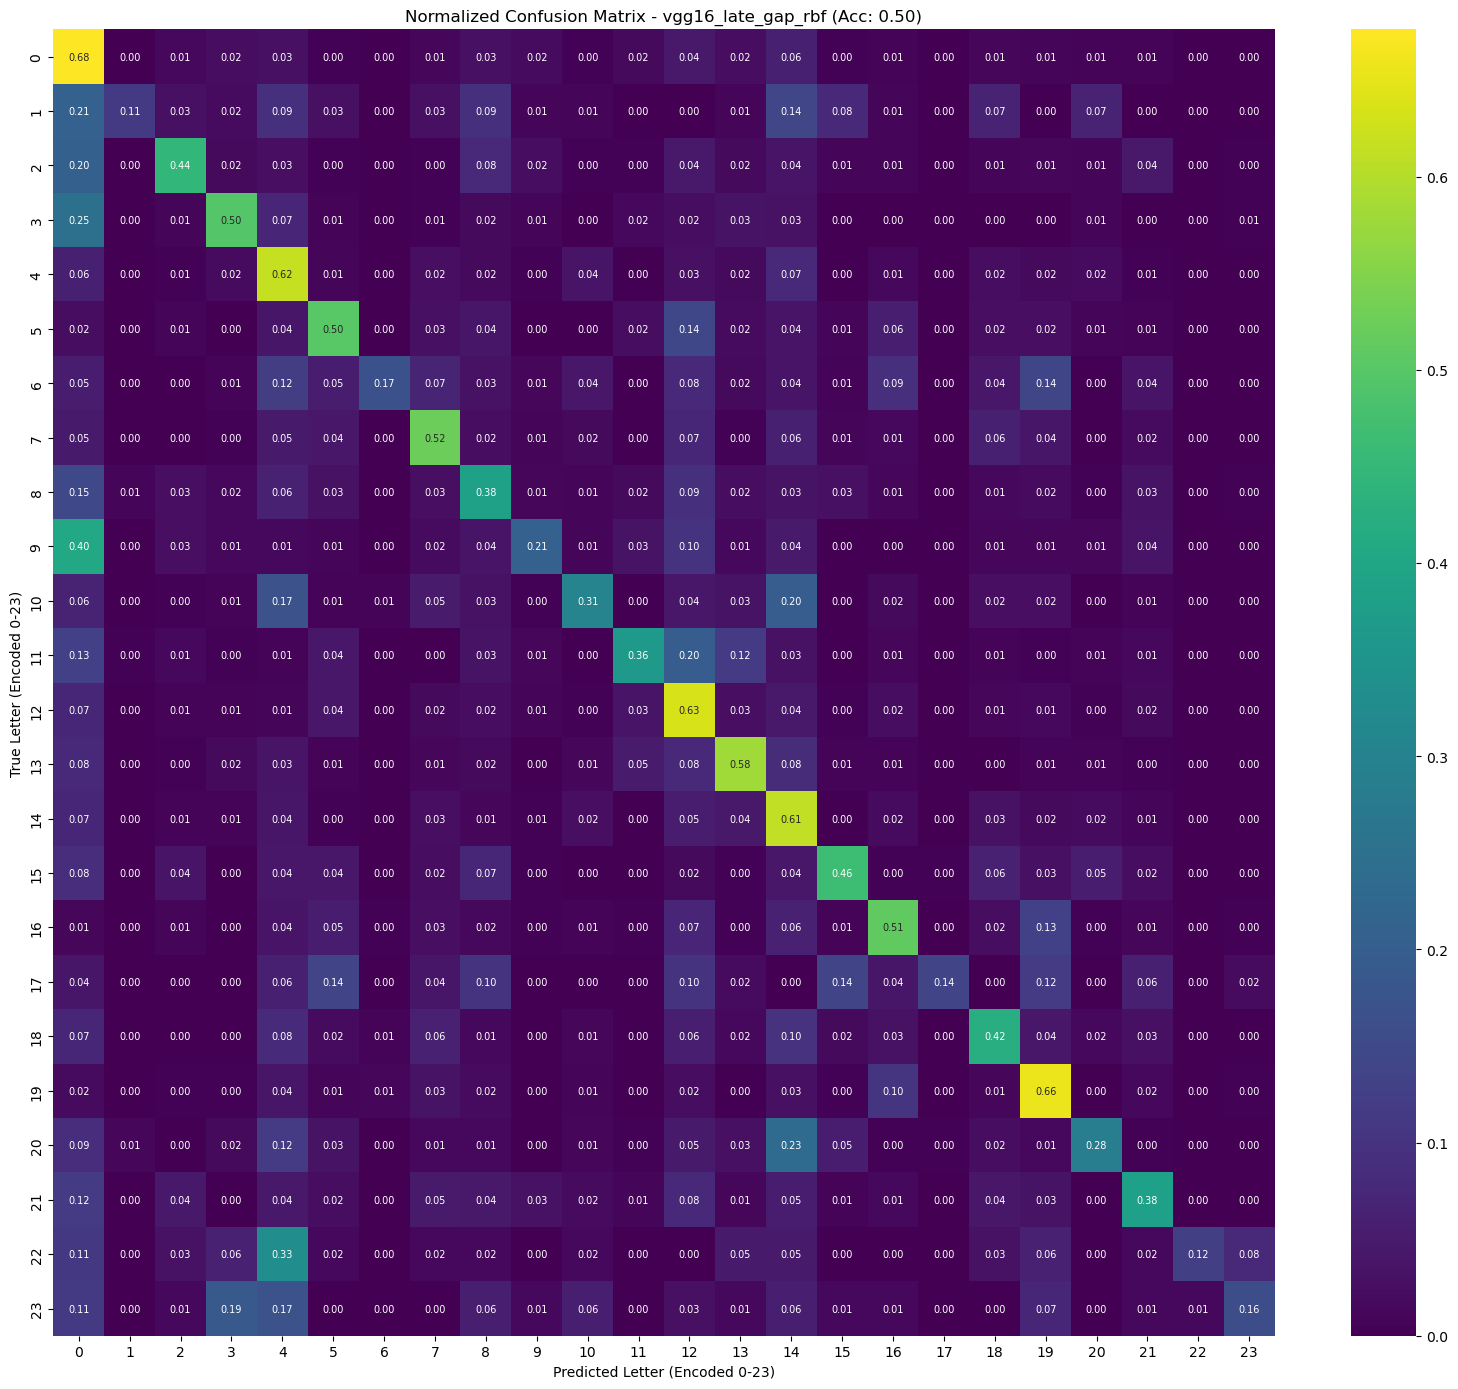


Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.68      0.53      1044
           1       0.41      0.11      0.18       106
           2       0.53      0.44      0.48       304
           3       0.62      0.50      0.55       379
           4       0.49      0.62      0.55       787
           5       0.55      0.50      0.52       534
           6       0.55      0.17      0.26       166
           7       0.47      0.52      0.50       433
           8       0.44      0.38      0.41       589
           9       0.45      0.21      0.28       356
          10       0.50      0.31      0.38       405
          11       0.57      0.36      0.44       480
          12       0.49      0.63      0.55       975
          13       0.55      0.58      0.56       543
          14       0.49      0.61      0.54       994
          15       0.53      0.46      0.49       224
          16       0.58      0.51      0.54       635
   

final_accuracy,0.50241
final_macro_f1,0.42918
final_weighted_f1,0.49122


In [4]:
config_late_gap = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,   # Dataset was augmented physically, no weight needed
    "cache_size": 5000,     
    "random_state": 42,
    "feature_dimensions": 512,
    "pooling_strategy": "GAP",
    "vgg16_blocks": "all"
}

train_and_evaluate_svm(
    config_params=config_late_gap, 
    data_dir="../data/extracted_features", 
    run_name="vgg16_late_gap_rbf"
)


Starting Experiment: vgg16_early_gap_rbf
Loaded Train Set - X: (100224, 256), y: (100224,)
Loaded Test Set  - X: (10977, 256), y: (10977,)
Training RBF Kernel SVC on 256-D features...
Training complete. Generating predictions...
Accuracy: 0.3860 | Macro-F1: 0.3002 | Weighted-F1: 0.3635


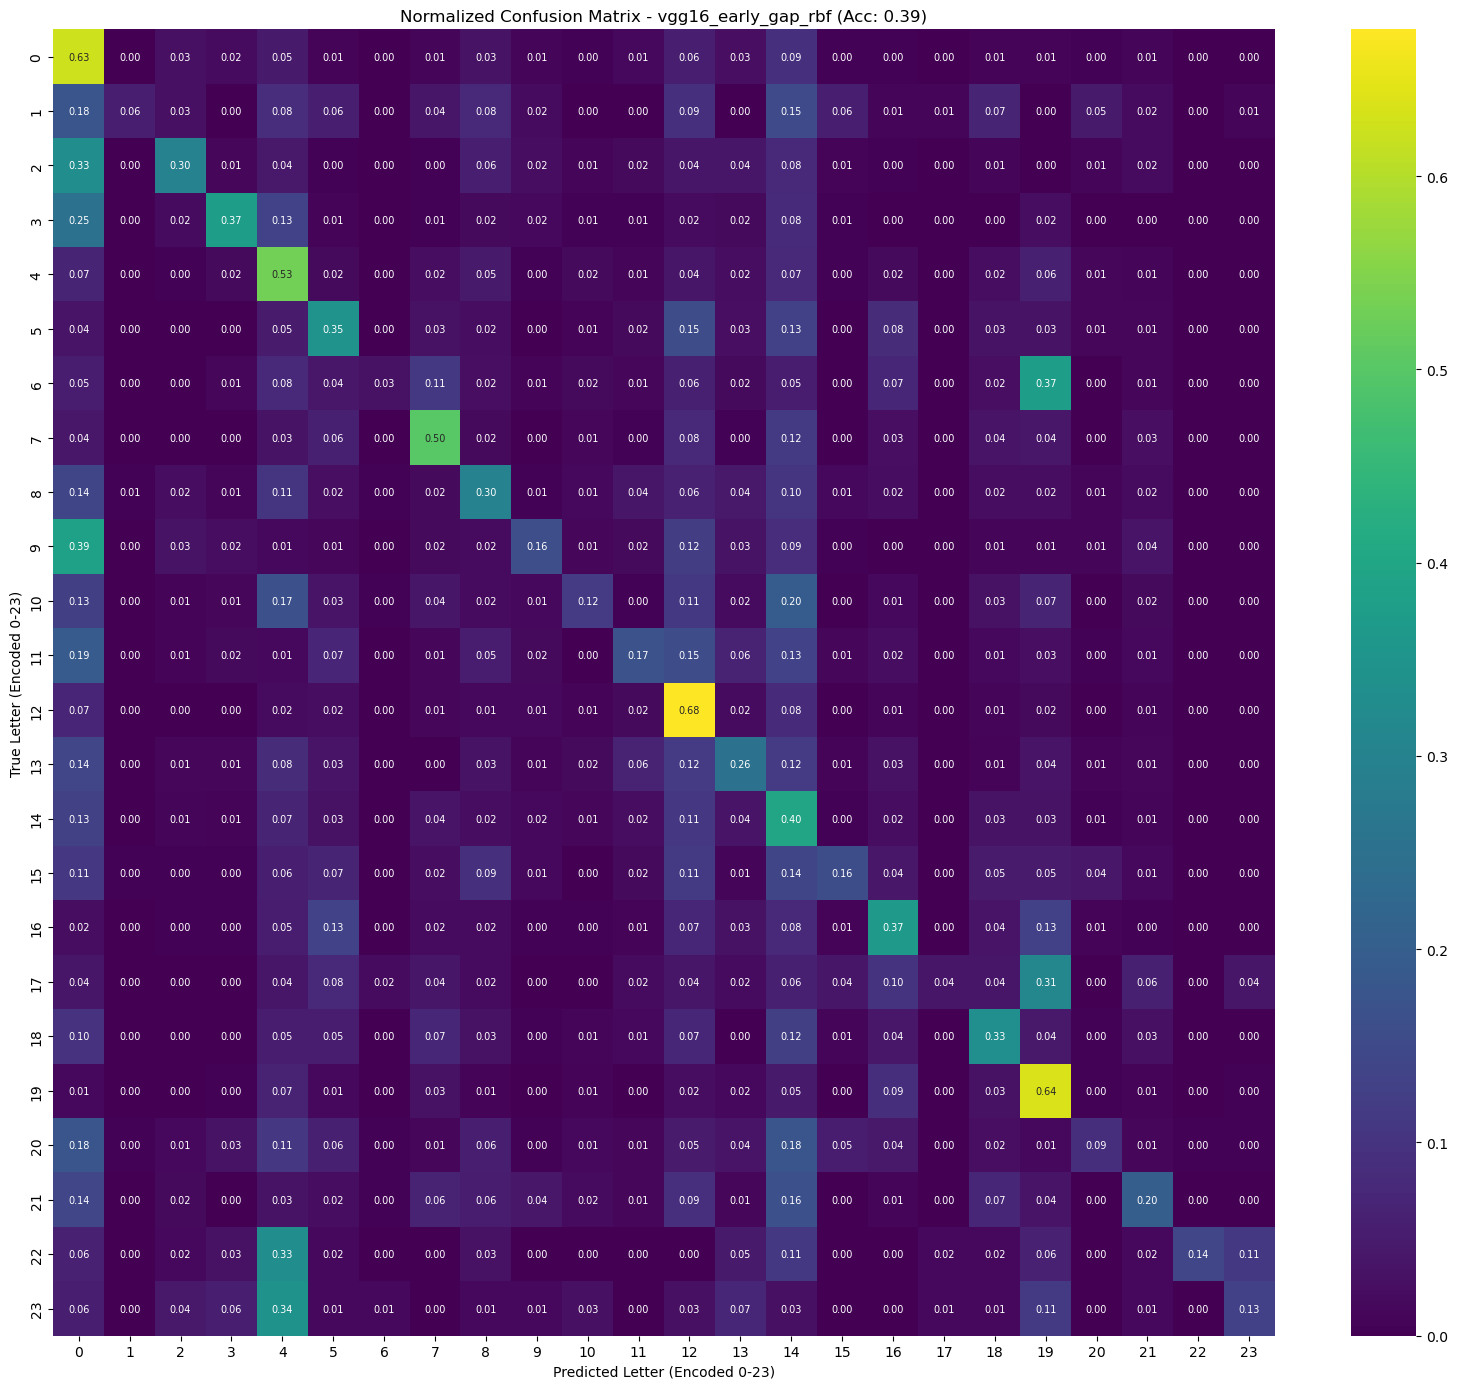


Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.63      0.46      1044
           1       0.40      0.06      0.10       106
           2       0.45      0.30      0.36       304
           3       0.57      0.37      0.45       379
           4       0.39      0.53      0.45       787
           5       0.34      0.35      0.34       534
           6       0.25      0.03      0.05       166
           7       0.46      0.50      0.48       433
           8       0.36      0.30      0.32       589
           9       0.35      0.16      0.22       356
          10       0.32      0.12      0.17       405
          11       0.32      0.17      0.22       480
          12       0.45      0.68      0.54       975
          13       0.34      0.26      0.29       543
          14       0.28      0.40      0.33       994
          15       0.35      0.16      0.22       224
          16       0.46      0.37      0.41       635
   

final_accuracy,0.38599
final_macro_f1,0.30017
final_weighted_f1,0.36349


In [5]:
config_early_gap = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None, 
    "cache_size": 5000,     
    "random_state": 42,
    "feature_dimensions": 256,
    "pooling_strategy": "GAP",
    "vgg16_blocks": "1_to_3"
}

train_and_evaluate_svm(
    config_params=config_early_gap, 
    data_dir="../data/extracted_features_early", 
    run_name="vgg16_early_gap_rbf"
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Starting Experiment: vgg16_spp2x2_augmented_rbf
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Training RBF Kernel SVC on 2048-D features...
Training complete. Generating predictions...
Accuracy: 0.6603 | Macro-F1: 0.6054 | Weighted-F1: 0.6555


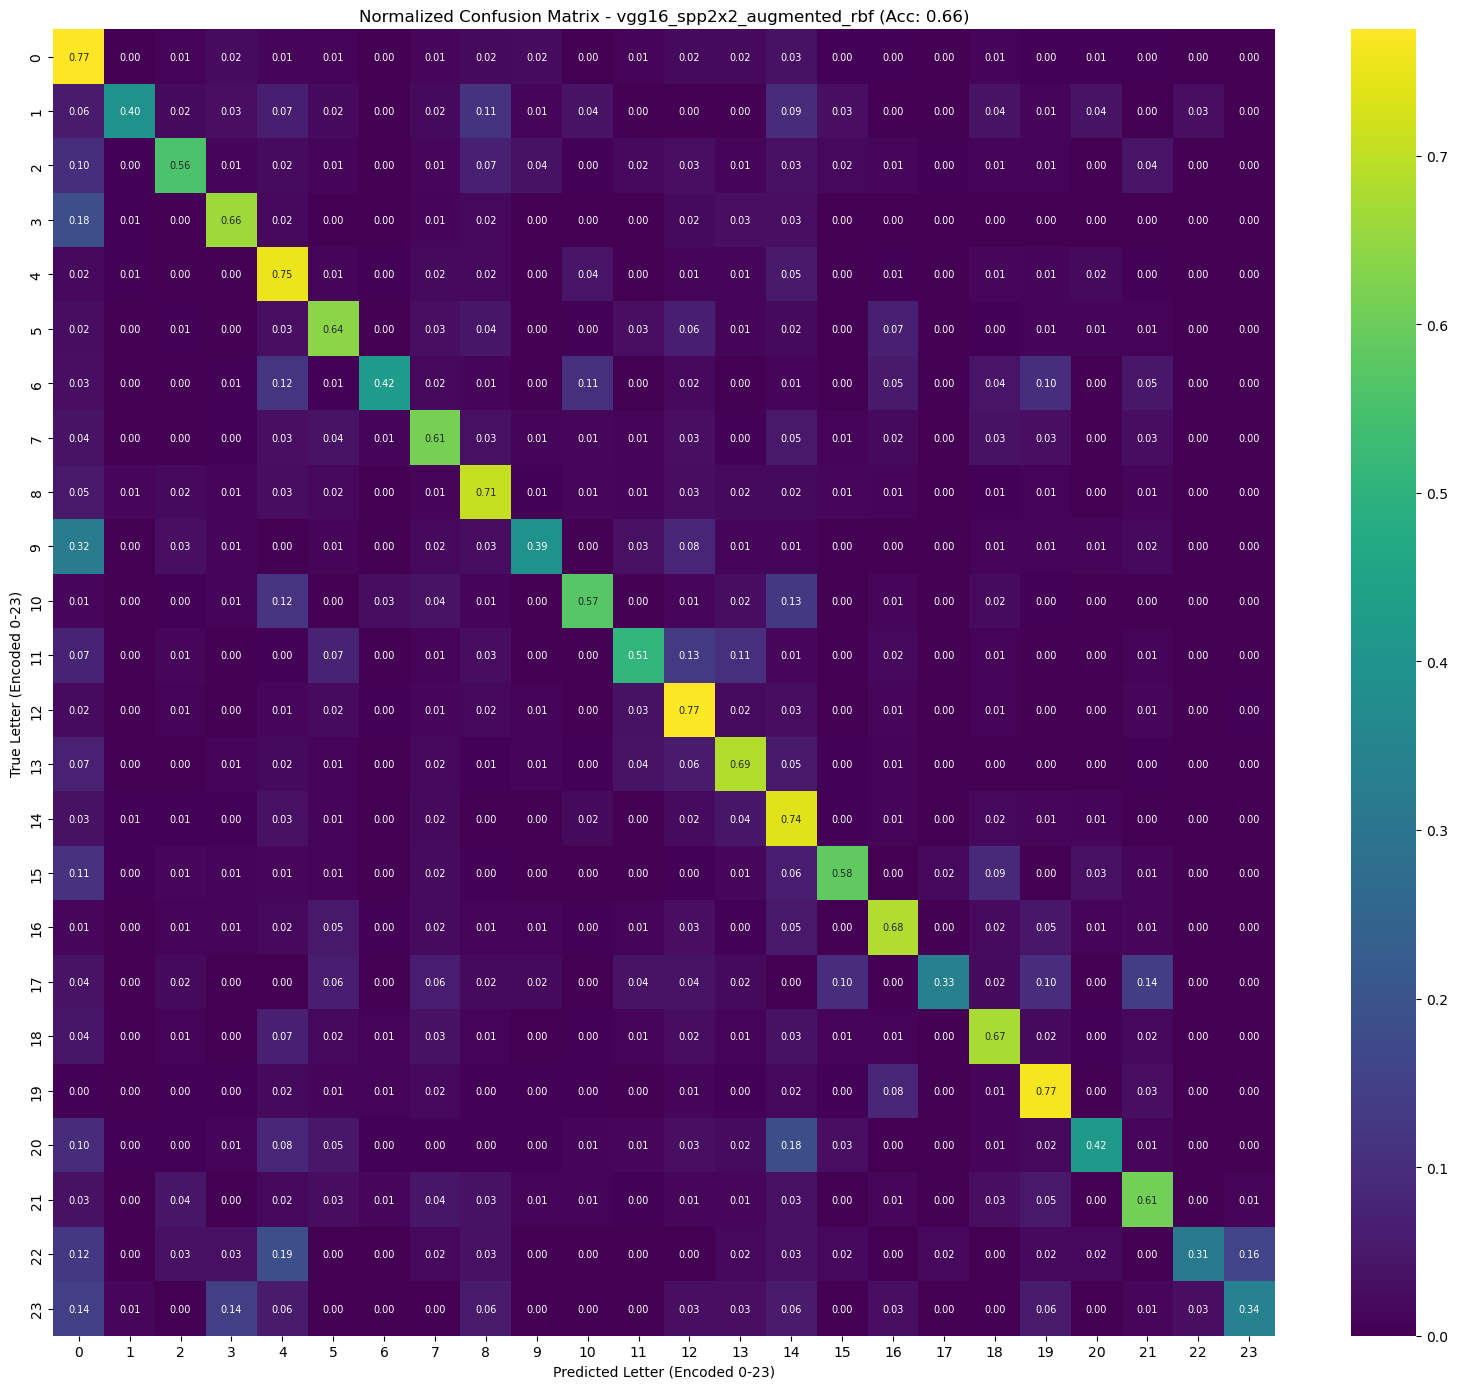


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.77      0.67      1044
           1       0.60      0.40      0.48       106
           2       0.63      0.56      0.59       304
           3       0.75      0.66      0.70       379
           4       0.66      0.75      0.70       787
           5       0.63      0.64      0.64       534
           6       0.64      0.42      0.51       166
           7       0.57      0.61      0.59       433
           8       0.69      0.71      0.70       589
           9       0.66      0.39      0.49       356
          10       0.67      0.57      0.62       405
          11       0.66      0.51      0.57       480
          12       0.70      0.77      0.74       975
          13       0.63      0.69      0.66       543
          14       0.64      0.74      0.69       994
          15       0.70      0.58      0.64       224
          16       0.70      0.68      0.69       635
   

final_accuracy,0.66029
final_macro_f1,0.60542
final_weighted_f1,0.65551


In [3]:
config_spp = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,  
    "cache_size": 6000,     
    "random_state": 42,
    "feature_dimensions": 2048,
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

train_and_evaluate_svm(
    config_params=config_spp, 
    data_dir="../data/extracted_features_SPP", 
    run_name="vgg16_spp2x2_augmented_rbf"
)

In [ ]:
# 1. Configuration for the Block 4 Exact RBF Test
config_block4_spp = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 10.0,              # Transplanted from your Block 5 optimization
    "gamma": "scale",       # The mathematical wildcard (see warning below)
    "class_weight": None,   # Dataset is physically balanced offline
    "cache_size": 6000,     
    "random_state": 42,
    "feature_dimensions": 2048,
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "block4" # Crucial update for your W&B tracking
}

# 2. Execute the evaluation (assuming you already extracted Block 4 SPP features)
# NOTE: Ensure the data_dir points to the folder containing your BLOCK 4 features!
train_and_evaluate_svm(
    config_params=config_block4_spp, 
    data_dir="../data/extracted_features_block4_SPP", 
    run_name="vgg16_block4_spp2x2_augmented_exact_rbf"
)


Starting Experiment: vgg16_block4_spp2x2_augmented_exact_rbf
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Training RBF Kernel SVC on 2048-D features...


# Training Takes Too Long for a first impression

## Instead: use Nystroem Kernel Approximation for a first overview

In [6]:
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def train_and_evaluate_svm(config_params, data_dir, run_name, project_name="odysseus"):
    """
    Universal function to load pre-split data, train an SVM (Exact or Approximated), 
    evaluate it, and log to W&B.
    """
    # 1. Initialize Weights & Biases
    wandb.init(project=project_name, name=run_name, job_type="modeling", config=config_params)
    config = wandb.config
    
    print(f"\n{'='*50}\nStarting Experiment: {run_name}\n{'='*50}")

    # 2. Load the pre-split arrays
    X_train = np.load(os.path.join(data_dir, "X_train.npy"))
    y_train = np.load(os.path.join(data_dir, "y_train.npy"))
    X_test = np.load(os.path.join(data_dir, "X_test.npy"))
    y_test = np.load(os.path.join(data_dir, "y_test.npy"))

    print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
    print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

    # 3. Standard Scaling 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- THE FIX: Compute dynamic gamma for Nystroem if necessary ---
    resolved_gamma = config.gamma
    if isinstance(resolved_gamma, str):
        if resolved_gamma == "scale":
            resolved_gamma = 1.0 / (X_train_scaled.shape[1] * X_train_scaled.var())
        elif resolved_gamma == "auto":
            resolved_gamma = 1.0 / X_train_scaled.shape[1]
    # ----------------------------------------------------------------

    # 4. Train the SVM (With Approximation Toggle)
    if config.get("approximate_kernel", False):
        n_comp = config.get("n_components", 2000)
        print(f"Training APPROXIMATED RBF Kernel (Nystroem + LinearSVC) with {n_comp} components...")
        print(f"Calculated Gamma: {resolved_gamma:.6f}")
        
        nystroem = Nystroem(
            gamma=resolved_gamma, # Use the explicitly calculated float here
            random_state=config.random_state,
            n_components=n_comp
        )
        linear_svm = LinearSVC(
            C=config.C,
            class_weight=config.class_weight,
            random_state=config.random_state,
            max_iter=3000,
            dual=False 
        )
        svm_clf = Pipeline([
            ("feature_map", nystroem),
            ("svm", linear_svm)
        ])
    else:
        print(f"Training EXACT RBF Kernel SVC on {X_train.shape[1]}-D features...")
        svm_clf = SVC(
            kernel=config.kernel,
            C=config.C,
            gamma=config.gamma, # Standard SVC can safely handle "scale" natively
            class_weight=config.class_weight,
            cache_size=config.cache_size,
            random_state=config.random_state
        )
        
    svm_clf.fit(X_train_scaled, y_train)

    # 5. Evaluate
    print("Training complete. Generating predictions...")
    y_pred = svm_clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

    # 6. Log Summary Metrics to W&B
    wandb.run.summary["final_accuracy"] = accuracy
    wandb.run.summary["final_macro_f1"] = macro_f1
    wandb.run.summary["final_weighted_f1"] = weighted_f1

    # 7. Generate and Log Annotated Heatmap
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})
    plt.title(f"Normalized Confusion Matrix - {run_name} (Acc: {accuracy:.2f})")
    plt.xlabel("Predicted Letter (Encoded 0-23)")
    plt.ylabel("True Letter (Encoded 0-23)")
    plt.tight_layout()

    cm_filename = f"svm_cm_{run_name}.png"
    plt.savefig(cm_filename, dpi=300)
    wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
    plt.show()

    # 8. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Close the W&B run cleanly
    wandb.finish()


Starting Experiment: vgg16_late_gap_approx_rbf
Loaded Train Set - X: (100224, 512), y: (100224,)
Loaded Test Set  - X: (10977, 512), y: (10977,)
Training APPROXIMATED RBF Kernel (Nystroem + LinearSVC) with 2000 components...
Calculated Gamma: 0.001953
Training complete. Generating predictions...
Accuracy: 0.4961 | Macro-F1: 0.4133 | Weighted-F1: 0.4829


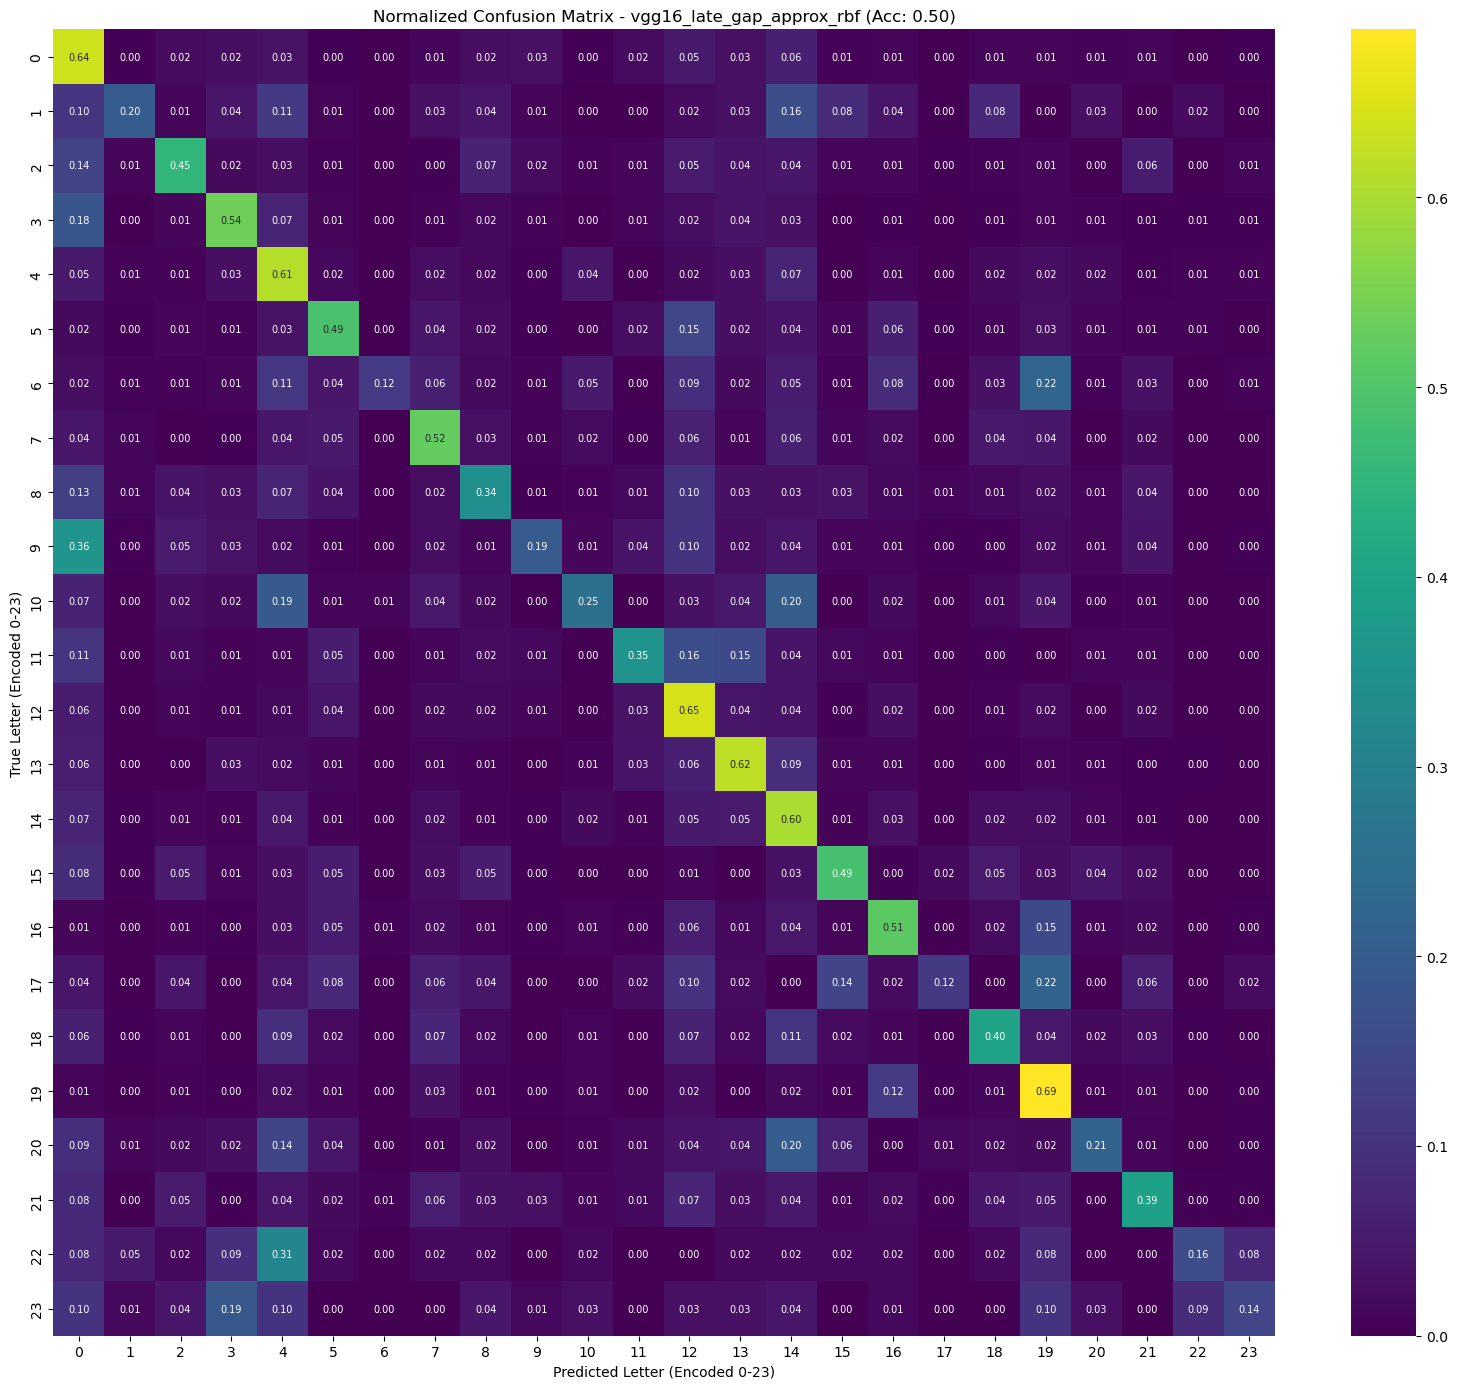


Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.64      0.54      1044
           1       0.33      0.20      0.25       106
           2       0.44      0.45      0.45       304
           3       0.55      0.54      0.54       379
           4       0.49      0.61      0.55       787
           5       0.52      0.49      0.50       534
           6       0.50      0.12      0.19       166
           7       0.46      0.52      0.49       433
           8       0.50      0.34      0.41       589
           9       0.43      0.19      0.27       356
          10       0.47      0.25      0.33       405
          11       0.56      0.35      0.43       480
          12       0.51      0.65      0.57       975
          13       0.49      0.62      0.55       543
          14       0.50      0.60      0.54       994
          15       0.45      0.49      0.47       224
          16       0.56      0.51      0.54       635
   

final_accuracy,0.49613
final_macro_f1,0.41327
final_weighted_f1,0.48291


In [7]:
config_late_gap = {
    "model_type": "LinearSVC_Nystroem",
    "kernel": "rbf",
    "approximate_kernel": True,
    "n_components": 2000,
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,   
    "cache_size": 4000,     
    "random_state": 42,
    "feature_dimensions": 512,
    "pooling_strategy": "GAP",
    "vgg16_blocks": "all"
}

train_and_evaluate_svm(
    config_params=config_late_gap, 
    data_dir="../data/extracted_features", 
    run_name="vgg16_late_gap_approx_rbf"
)


Starting Experiment: vgg16_early_gap_approx_rbf
Loaded Train Set - X: (100224, 256), y: (100224,)
Loaded Test Set  - X: (10977, 256), y: (10977,)
Training APPROXIMATED RBF Kernel (Nystroem + LinearSVC) with 2000 components...
Calculated Gamma: 0.003906
Training complete. Generating predictions...
Accuracy: 0.3782 | Macro-F1: 0.2936 | Weighted-F1: 0.3514


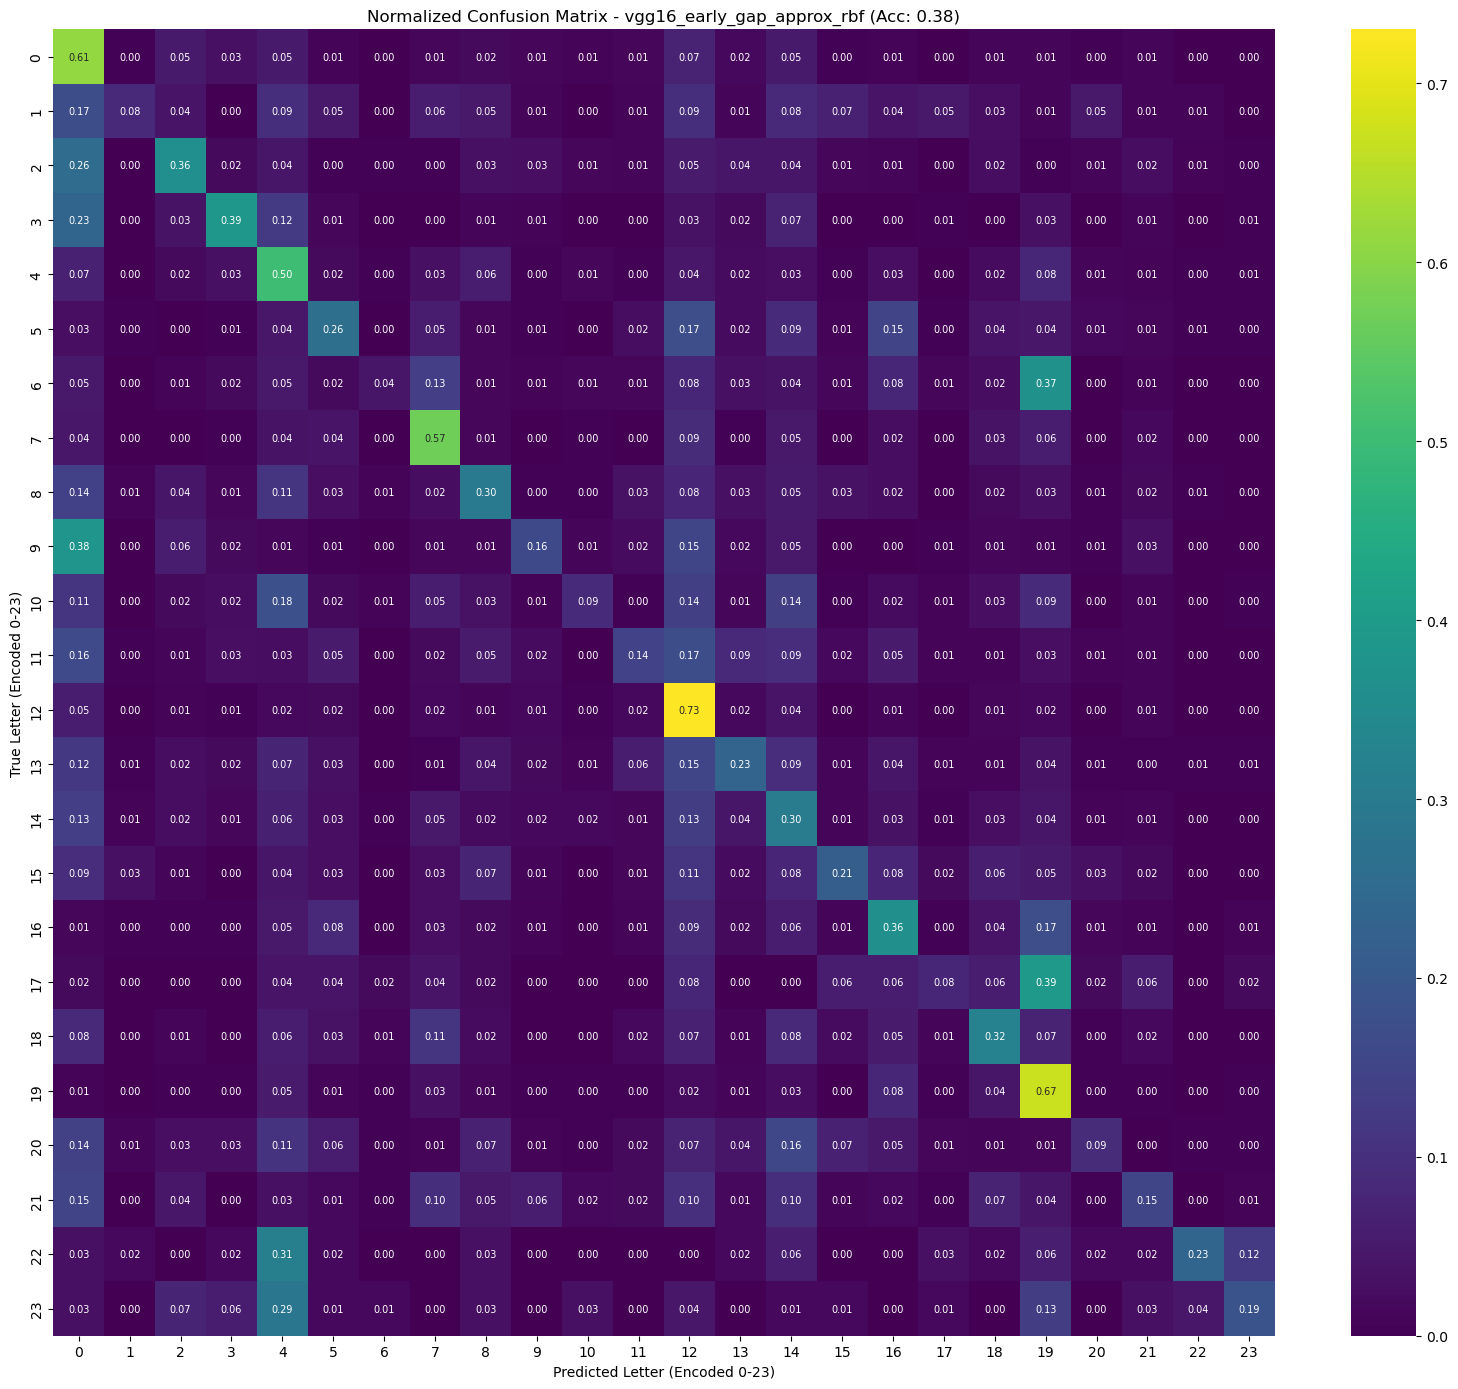


Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.61      0.47      1044
           1       0.18      0.08      0.12       106
           2       0.32      0.36      0.34       304
           3       0.49      0.39      0.43       379
           4       0.39      0.50      0.44       787
           5       0.34      0.26      0.30       534
           6       0.17      0.04      0.07       166
           7       0.41      0.57      0.48       433
           8       0.38      0.30      0.33       589
           9       0.31      0.16      0.21       356
          10       0.33      0.09      0.14       405
          11       0.30      0.14      0.19       480
          12       0.43      0.73      0.54       975
          13       0.34      0.23      0.28       543
          14       0.32      0.30      0.31       994
          15       0.29      0.21      0.25       224
          16       0.39      0.36      0.37       635
   

final_accuracy,0.37815
final_macro_f1,0.29365
final_weighted_f1,0.35142


In [8]:
config_early_gap = {
    "model_type": "LinearSVC_Nystroem",
    "kernel": "rbf",
    "approximate_kernel": True,
    "n_components": 2000,
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,   
    "cache_size": 4000,     
    "random_state": 42,
    "feature_dimensions": 256,
    "pooling_strategy": "GAP",
    "vgg16_blocks": "1_to_3"
}

train_and_evaluate_svm(
    config_params=config_late_gap, 
    data_dir="../data/extracted_features_early", 
    run_name="vgg16_early_gap_approx_rbf"
)


Starting Experiment: vgg16_spp2x2_approx_rbf
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Training APPROXIMATED RBF Kernel (Nystroem + LinearSVC) with 2000 components...
Calculated Gamma: 0.000488
Training complete. Generating predictions...
Accuracy: 0.6404 | Macro-F1: 0.5797 | Weighted-F1: 0.6343


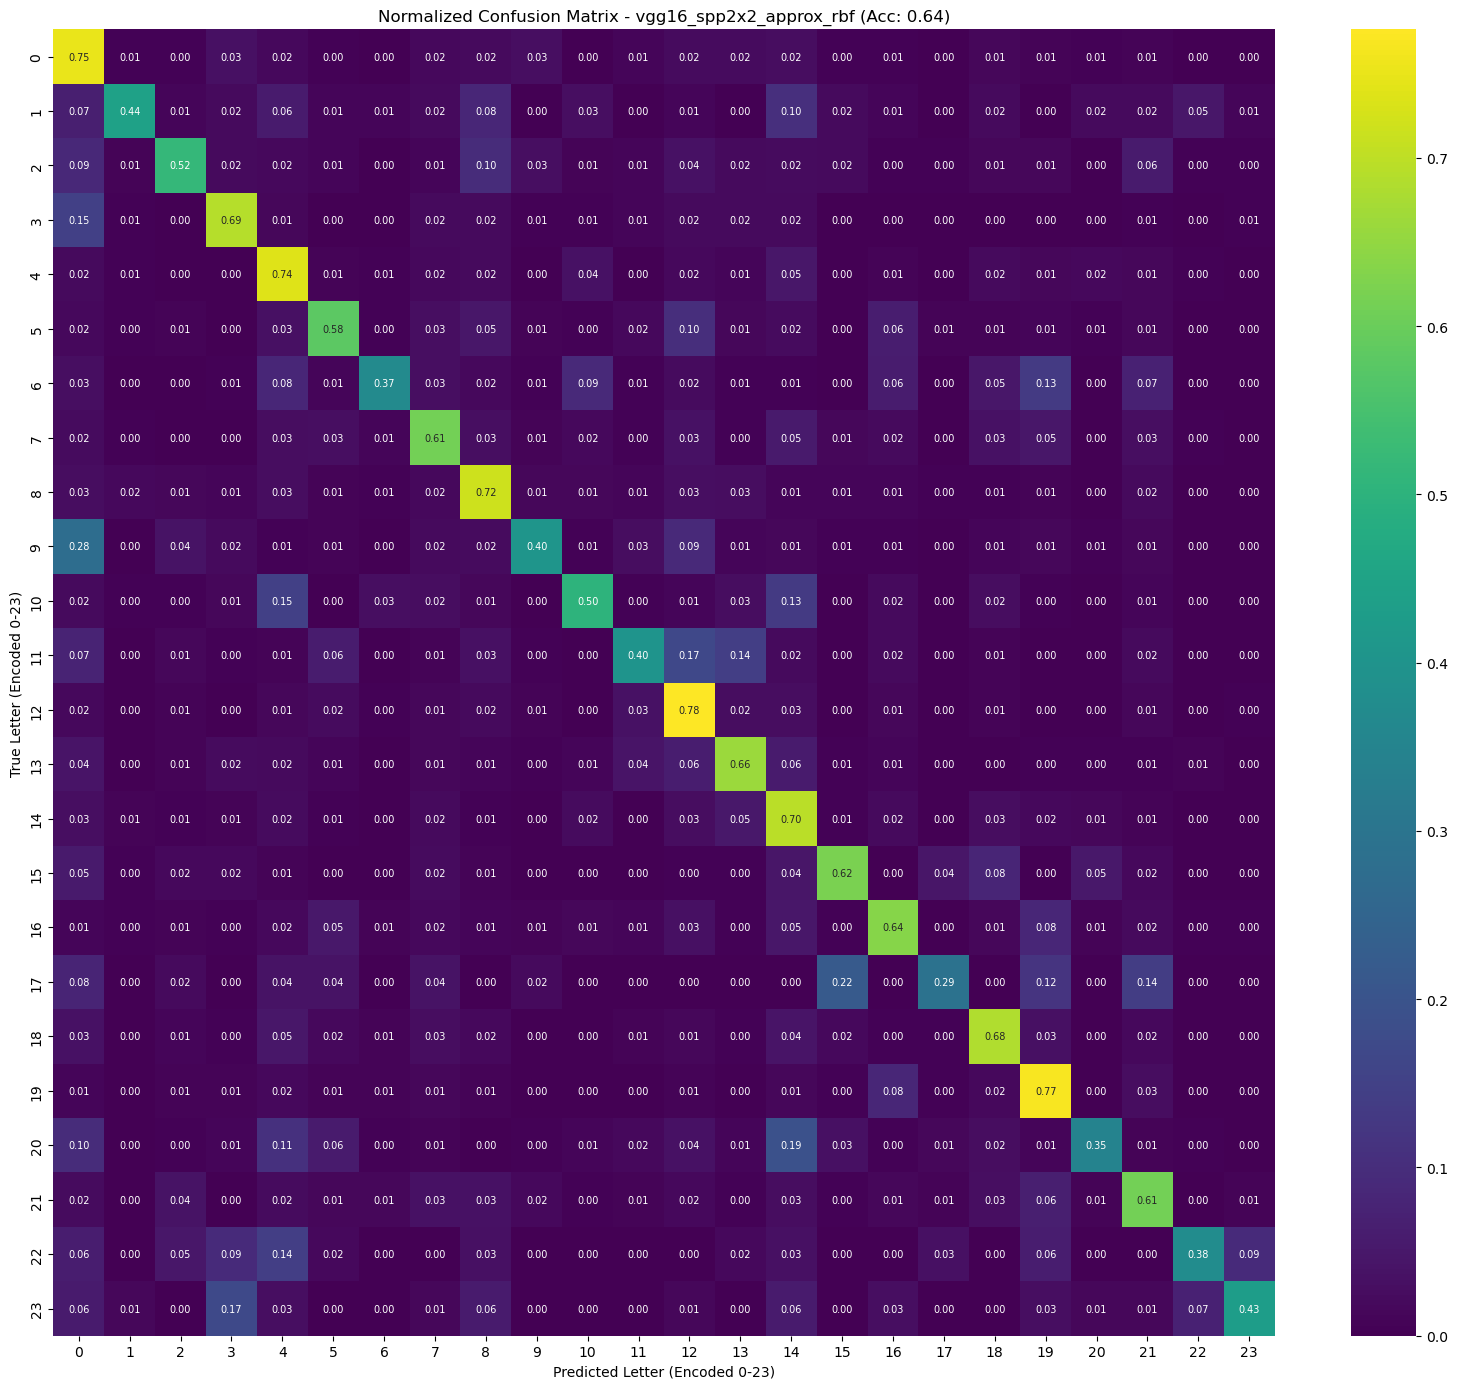


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.75      0.69      1044
           1       0.51      0.44      0.47       106
           2       0.62      0.52      0.56       304
           3       0.69      0.69      0.69       379
           4       0.66      0.74      0.70       787
           5       0.65      0.58      0.61       534
           6       0.54      0.37      0.44       166
           7       0.58      0.61      0.60       433
           8       0.66      0.72      0.69       589
           9       0.62      0.40      0.49       356
          10       0.64      0.50      0.56       405
          11       0.61      0.40      0.48       480
          12       0.67      0.78      0.72       975
          13       0.60      0.66      0.63       543
          14       0.64      0.70      0.67       994
          15       0.65      0.62      0.63       224
          16       0.68      0.64      0.66       635
   

final_accuracy,0.64043
final_macro_f1,0.57972
final_weighted_f1,0.63433


In [9]:
config_spp = {
    "model_type": "LinearSVC_Nystroem",
    "kernel": "rbf",
    "approximate_kernel": True,
    "n_components": 2000,
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,  
    "cache_size": 4000,     
    "random_state": 42,
    "feature_dimensions": 2048,
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

train_and_evaluate_svm(
    config_params=config_spp, 
    data_dir="../data/extracted_features_SPP", 
    run_name="vgg16_spp2x2_approx_rbf"
)

# Faster SVM Model (LinearSVC)








In [6]:
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def train_and_evaluate_linearsvc(config_params, data_dir, run_name, project_name="odysseus"):
    """
    Universal function to load pre-split data, train a highly performant LinearSVC, 
    evaluate it, and log to W&B.
    """
    # 1. Initialize Weights & Biases
    wandb.init(project=project_name, name=run_name, job_type="modeling", config=config_params)
    config = wandb.config
    
    print(f"\n{'='*50}\nStarting Fast Linear Experiment: {run_name}\n{'='*50}")

    # 2. Load the pre-split arrays (Data Leakage explicitly prevented here)
    X_train = np.load(os.path.join(data_dir, "X_train.npy"))
    y_train = np.load(os.path.join(data_dir, "y_train.npy"))
    X_test = np.load(os.path.join(data_dir, "X_test.npy"))
    y_test = np.load(os.path.join(data_dir, "y_test.npy"))

    print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
    print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

    # 3. Standard Scaling 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Train the Fast Linear SVM
    print(f"Training LinearSVC on {X_train.shape[1]}-D features (This will hopefully be fast)...")
    svm_clf = LinearSVC(
        C=config.C,
        class_weight=config.class_weight,
        random_state=config.random_state,
        max_iter=config.max_iter,
        dual=config.dual,       # CRITICAL: Must be False when N_samples > N_features
        verbose=0
    )
    svm_clf.fit(X_train_scaled, y_train)

    # 5. Evaluate
    print("Training complete. Generating predictions...")
    y_pred = svm_clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

    # 6. Log Summary Metrics to W&B
    wandb.run.summary["final_accuracy"] = accuracy
    wandb.run.summary["final_macro_f1"] = macro_f1
    wandb.run.summary["final_weighted_f1"] = weighted_f1

    # 7. Generate and Log Annotated Heatmap with Greek Labels
    greek_labels = [
        "Alpha (Α)", "Beta (Β)", "Chi (Χ)", "Delta (Δ)", "Epsilon (Ε)", 
        "Eta (Η)", "Gamma (Γ)", "Iota (Ι)", "Kappa (Κ)", "Lambda (Λ)", 
        "LSigma (Ϲ)", "Mu (Μ)", "Nu (Ν)", "Omega (Ω)", "Omicron (Ο)", 
        "Phi (Φ)", "Pi (Π)", "Psi (Ψ)", "Rho (Ρ)", "Tau (Τ)", "Theta (Θ)", 
        "Upsilon (Υ)", "Xi (Ξ)", "Zeta (Ζ)"
    ]
    
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    plt.figure(figsize=(18, 16))
    
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7},
        xticklabels=greek_labels, yticklabels=greek_labels
    )
    plt.title(f"Normalized Confusion Matrix - {run_name} (Acc: {accuracy:.2f})")
    plt.xlabel("Predicted Letter")
    plt.ylabel("True Letter")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save with unique name to prevent overwriting
    cm_filename = f"linearsvc_cm_{run_name}.png"
    plt.savefig(cm_filename, dpi=300)
    wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
    plt.show()

    # 8. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Close the W&B run cleanly
    wandb.finish()


Starting Fast Linear Experiment: vgg16_spp2x2_augmented_linearsvc
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Training LinearSVC on 2048-D features (This will be blazingly fast)...
Training complete. Generating predictions...
Accuracy: 0.6311 | Macro-F1: 0.5691 | Weighted-F1: 0.6285


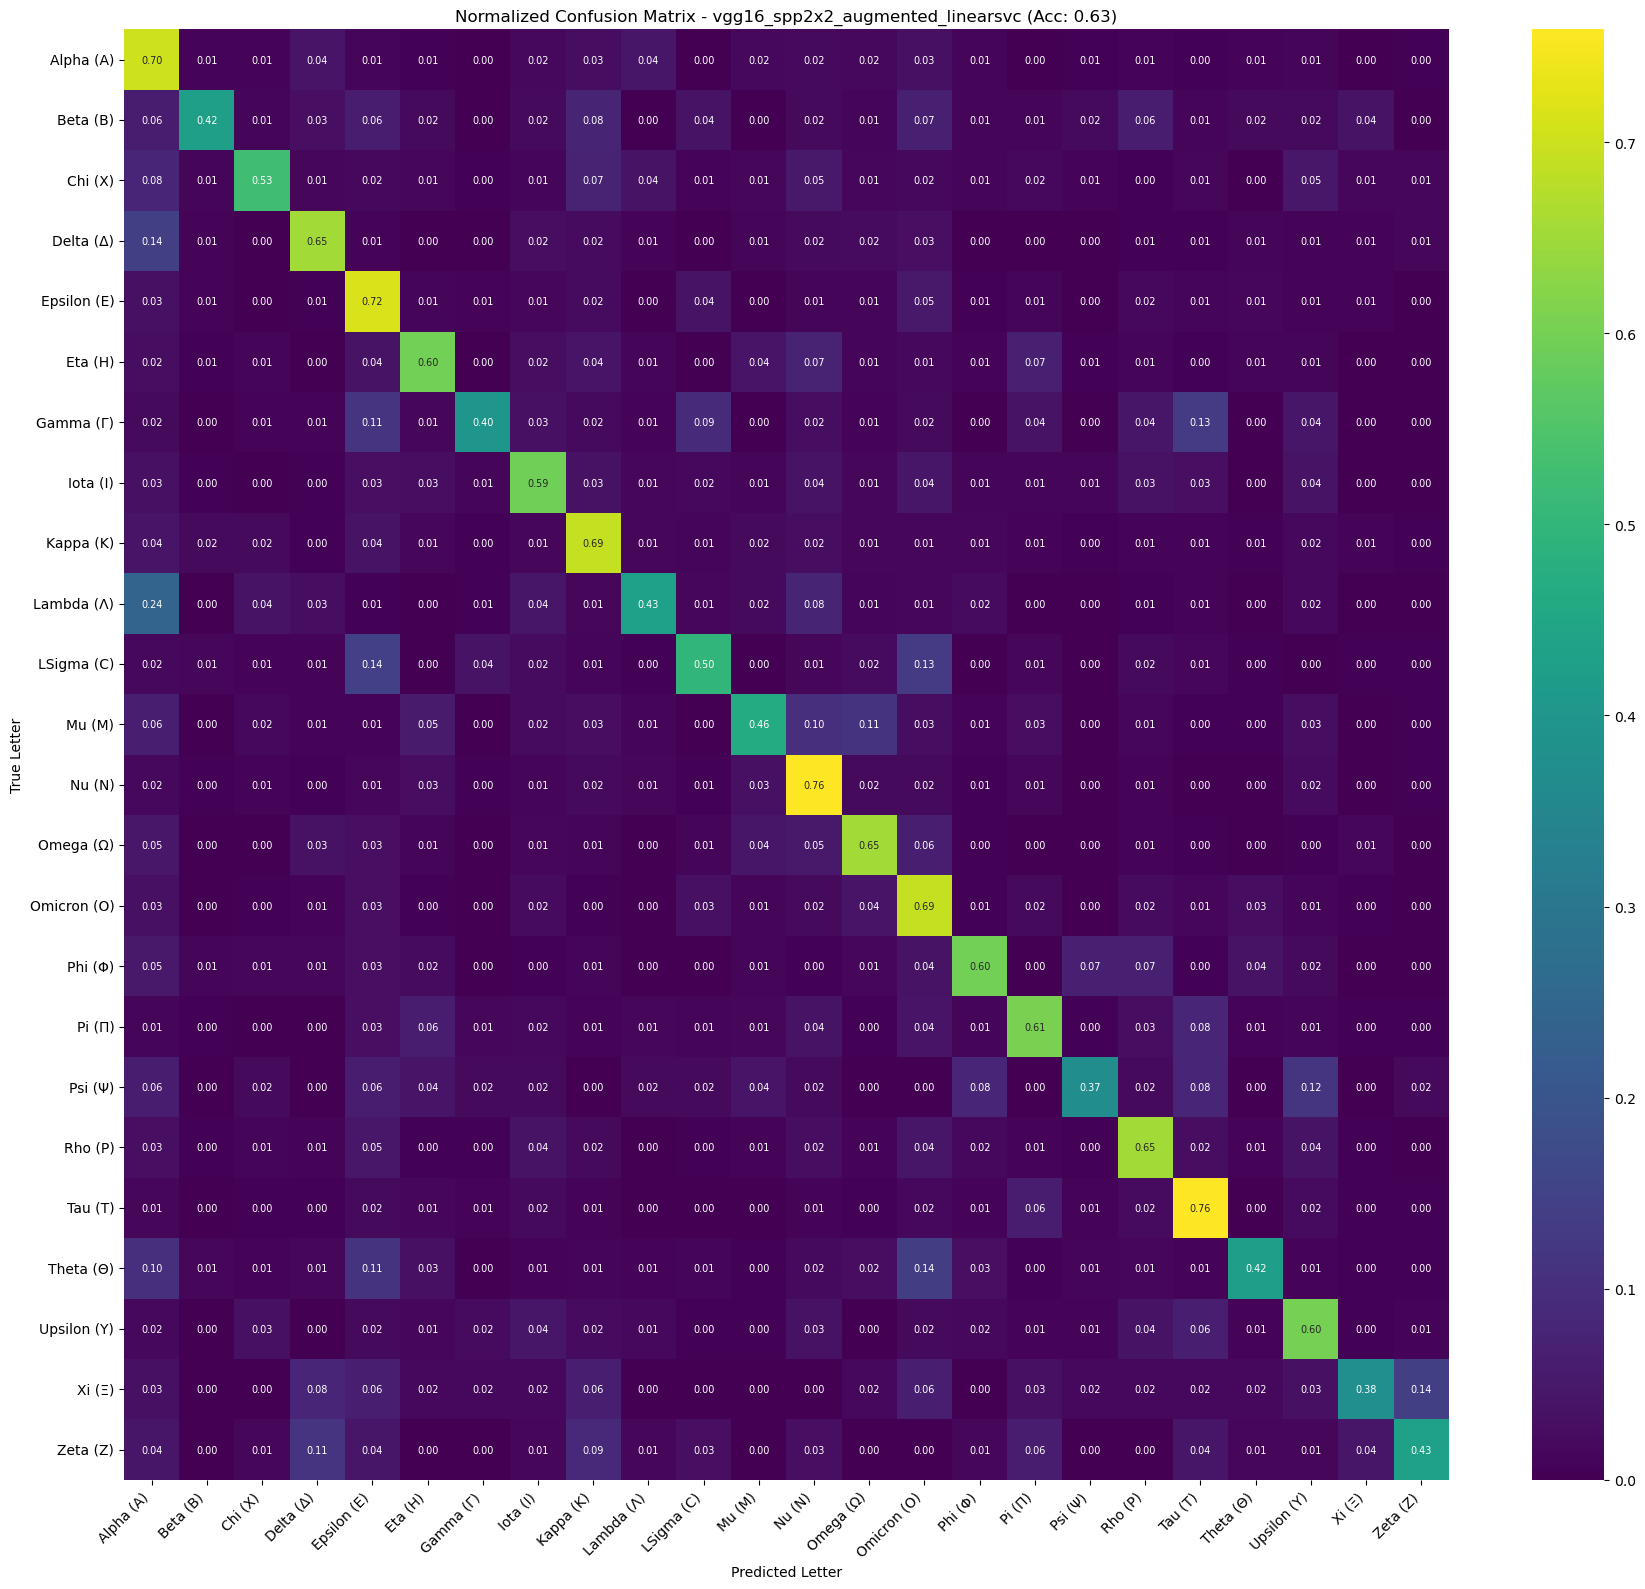


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.70      0.66      1044
           1       0.43      0.42      0.43       106
           2       0.63      0.53      0.57       304
           3       0.66      0.65      0.66       379
           4       0.63      0.72      0.67       787
           5       0.65      0.60      0.62       534
           6       0.49      0.40      0.44       166
           7       0.56      0.59      0.57       433
           8       0.66      0.69      0.67       589
           9       0.55      0.43      0.48       356
          10       0.61      0.50      0.55       405
          11       0.59      0.46      0.52       480
          12       0.70      0.76      0.73       975
          13       0.64      0.65      0.64       543
          14       0.65      0.69      0.67       994
          15       0.58      0.60      0.59       224
          16       0.69      0.61      0.65       635
   

final_accuracy,0.63114
final_macro_f1,0.56909
final_weighted_f1,0.62853


In [7]:
# 1. Tailored Configuration for LinearSVC
config_spp_linear = {
    "model_type": "LinearSVC",
    "C": 1.0,               
    "class_weight": None,   # Dataset is physically balanced
    "random_state": 42,
    "max_iter": 5000,       # High iteration limit for high-dimensional convergence
    "dual": False,          # CRITICAL: Forces primal optimization (seconds instead of hours)
    "feature_dimensions": 2048,
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

# 2. Execute the Fast Linear Evaluation
train_and_evaluate_linearsvc(
    config_params=config_spp_linear, 
    data_dir="../data/extracted_features_SPP", 
    run_name="vgg16_spp2x2_augmented_linearsvc"
)

# GridSearchCV: Hyperparameter tuning



Starting Exact RBF Halving Search
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Initializing Exact RBF SVC...
Initiating HalvingGridSearchCV...
Search starting across 9 combinations...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 11136
max_resources_: 100224
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 11136
Fitting 4 folds for each of 9 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 3
n_resources: 33408
Fitting 4 folds for each of 3 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 1
n_resources: 100224
Fitting 4 folds for each of 1 candidates, totalling 4 fits
[CV 3/4] END C=0.1, gamma=scale;, score=(train=0.148, test=0.108) total time= 3.6min
[CV 3/4] END C=0.1, gamma=0.001;, score=(train=0.027, test=0.016) total time= 3.7min
[CV 3/4] END C=0.1, gamma=0.01;, score=(train=0.004, test=0.003) total time= 3.8min
[CV 3/4] END 

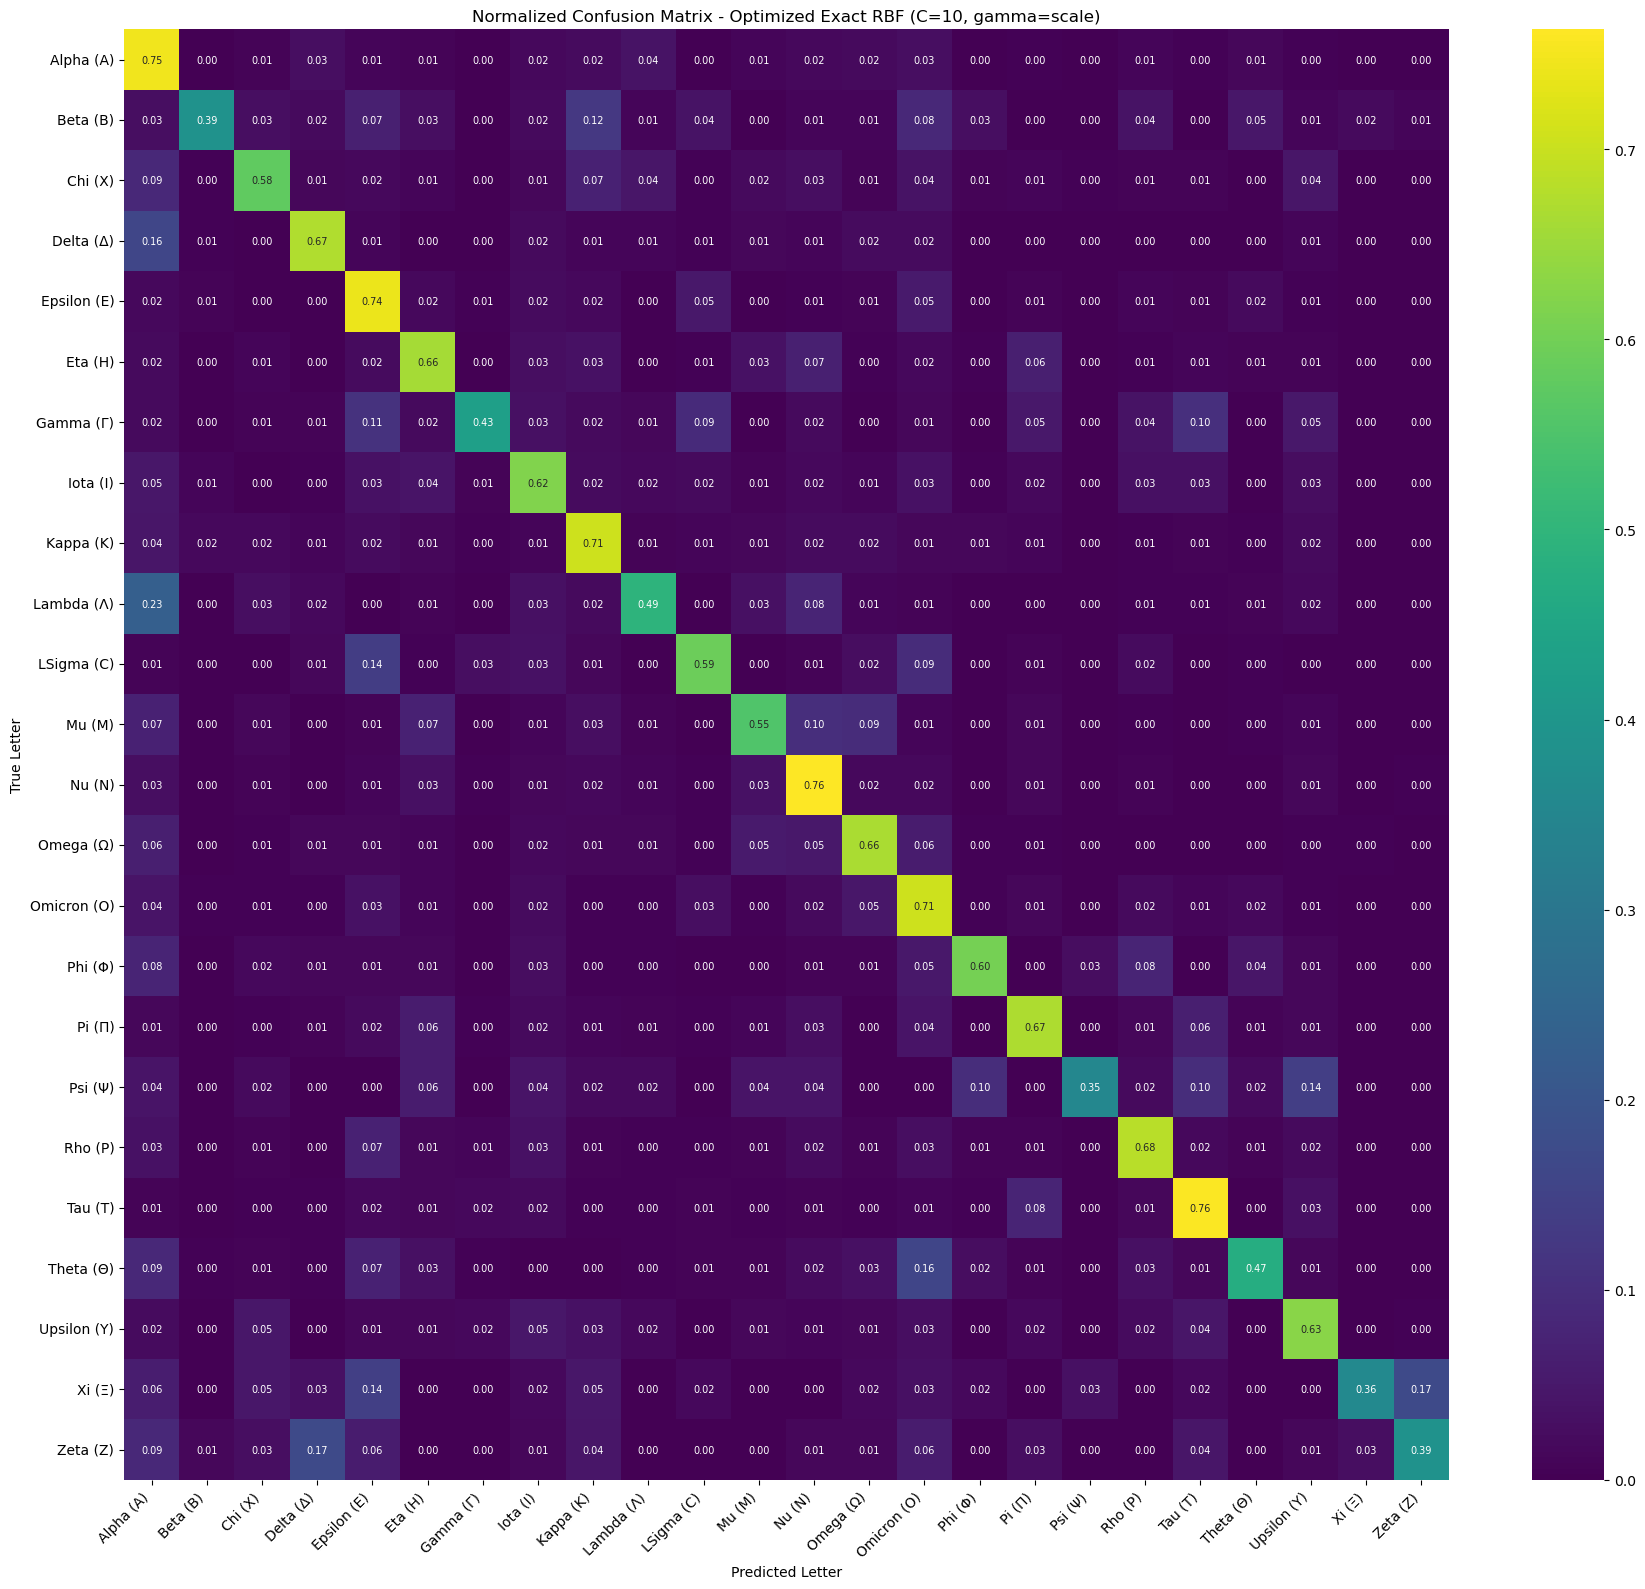


Final Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      1044
           1       0.53      0.39      0.45       106
           2       0.62      0.58      0.60       304
           3       0.72      0.67      0.70       379
           4       0.67      0.74      0.70       787
           5       0.63      0.66      0.64       534
           6       0.56      0.43      0.48       166
           7       0.55      0.62      0.58       433
           8       0.68      0.71      0.69       589
           9       0.60      0.49      0.54       356
          10       0.65      0.59      0.62       405
          11       0.63      0.55      0.59       480
          12       0.74      0.76      0.75       975
          13       0.64      0.66      0.65       543
          14       0.67      0.71      0.69       994
          15       0.74      0.60      0.66       224
          16       0.71      0.67      0.69       6

best_C,10
best_cv_macro_f1,0.68599
best_gamma,scale
final_test_accuracy,0.66275
final_test_macro_f1,0.6127
final_test_weighted_f1,0.6602


In [10]:
import os
import time
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTANT: You must explicitly enable the experimental halving search before importing it
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Configuration for the Halving Grid Search
config_rbf_halving = {
    "model_type": "SVC_RBF_HalvingSearch",
    "param_grid": {
        'C': [0.1, 1.0, 10.0],
        'gamma': ['scale', 0.001, 0.01]
    },
    "cv_folds": 4,          # Reduced from 5 to 3 to save critical compute time
    "cache_size": 6000,     # Dedicates 6GB of Unified Memory to the Gram matrix
    "feature_dimensions": 2048,
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

# 2. Initialize W&B
wandb.init(project="odysseus", name="vgg16_spp2x2_exact_rbf_tuning", job_type="tuning", config=config_rbf_halving)
config = wandb.config

print(f"\n{'='*50}\nStarting Exact RBF Halving Search\n{'='*50}")

# 3. Load the pre-split arrays
DATA_DIR = "../data/extracted_features_SPP"
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

# 4. Standard Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Define the Base Model and Halving Search
print("Initializing Exact RBF SVC...")
base_rbf_svm = SVC(
    kernel='rbf', 
    cache_size=config.cache_size, 
    random_state=42,
    class_weight=None
)

print("Initiating HalvingGridSearchCV...")
halving_search = HalvingGridSearchCV(
    estimator=base_rbf_svm,
    param_grid=config.param_grid,
    factor=3,               # Retains top 1/3 of candidates, triples data size per round
    cv=config.cv_folds,
    scoring='f1_macro',
    n_jobs=4,               # Parallelize the early rounds on M3 Performance Cores
    verbose=3,
    random_state=42
)

# 6. Execute the Search (The multi-day step)
start_time = time.time()
print(f"Search starting across {len(config.param_grid['C']) * len(config.param_grid['gamma'])} combinations...")

halving_search.fit(X_train_scaled, y_train)

elapsed_hours = (time.time() - start_time) / 3600
print(f"\nHalving Grid Search completed in {elapsed_hours:.2f} hours!")

# 7. Extract Best Model and Log Parameters
best_params = halving_search.best_params_
best_cv_score = halving_search.best_score_
print(f"Optimal RBF Parameters found: {best_params}")
print(f"Best Validation Macro-F1: {best_cv_score:.4f}")

wandb.run.summary["best_C"] = best_params['C']
wandb.run.summary["best_gamma"] = best_params['gamma']
wandb.run.summary["best_cv_macro_f1"] = best_cv_score

# 8. Final Evaluation on the Untouched Test Set
print("\nEvaluating the optimized exact RBF model on the test set...")
best_model = halving_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Final Test Accuracy: {accuracy:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

wandb.run.summary["final_test_accuracy"] = accuracy
wandb.run.summary["final_test_macro_f1"] = macro_f1
wandb.run.summary["final_test_weighted_f1"] = weighted_f1

# 9. Generate and Log Annotated Heatmap with Greek Labels
greek_labels = [
    "Alpha (Α)", "Beta (Β)", "Chi (Χ)", "Delta (Δ)", "Epsilon (Ε)", 
    "Eta (Η)", "Gamma (Γ)", "Iota (Ι)", "Kappa (Κ)", "Lambda (Λ)", 
    "LSigma (Ϲ)", "Mu (Μ)", "Nu (Ν)", "Omega (Ω)", "Omicron (Ο)", 
    "Phi (Φ)", "Pi (Π)", "Psi (Ψ)", "Rho (Ρ)", "Tau (Τ)", "Theta (Θ)", 
    "Upsilon (Υ)", "Xi (Ξ)", "Zeta (Ζ)"
]

cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(18, 16))

sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7},
    xticklabels=greek_labels, yticklabels=greek_labels
)
plt.title(f"Normalized Confusion Matrix - Optimized Exact RBF (C={best_params['C']}, gamma={best_params['gamma']})")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_filename = "halvingsearch_best_rbf_cm.png"
plt.savefig(cm_filename, dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
plt.show()

# 10. Classification Report
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))

# Close the W&B run cleanly
wandb.finish()